# FinBERT Analysis of Sustainability Reports

## Objective

This notebook applies two complementary Natural Language Processing (NLP) approaches to the processed sustainability reports.

First, the **ProsusAI/FinBERT** transformer model is employed to perform sentiment analysis on sustainability-related text segments. FinBERT is a BERT-based language model that has been fine-tuned on financial communications and is therefore well suited to analysing the language commonly found in corporate sustainability reports.

Second, a rule-based ESG classification approach is implemented using curated Environmental, Social, and Governance (ESG) keyword vocabularies. Each sentence is assigned to the ESG category with the highest number of keyword matches, providing an interpretable method for identifying the primary sustainability dimension discussed within the reports.

Together, these complementary analyses enable the identification of both the sentiment expressed in sustainability disclosures and the dominant ESG topics addressed by companies.

In [1]:
!pip install transformers
!pip install torch
!pip install sentencepiece
!pip install openpyxl

# 1. Import Required Libraries

This section imports the Python libraries required for loading the preprocessed sustainability reports, managing data, and performing sentiment analysis using the pretrained FinBERT transformer model.

In [2]:
import os
import glob
import zipfile

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from transformers import pipeline

# 2. Load the FinBERT Model


This notebook uses the pretrained **ProsusAI/FinBERT** model available through the Hugging Face Transformers library. FinBERT is a BERT-based transformer that has been fine-tuned on financial text, enabling it to classify the sentiment of financial and corporate disclosures into **Positive**, **Neutral**, or **Negative** categories.

The model is employed exclusively for sentiment analysis in this notebook. ESG category identification is performed separately using a rule-based keyword matching approach described later in the notebook.

**Reference**

Araci, D. (2019). *FinBERT: Financial Sentiment Analysis with Pre-trained Language Models*. arXiv:1908.10063.

In [3]:
finbert = pipeline(
    "sentiment-analysis",
    model="ProsusAI/finbert"
)

print("FinBERT loaded successfully!")

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  438MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  438MB            

model.safetensors: downloading bytes:           |  0.00B            

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

FinBERT loaded successfully!


# 3. Verify the FinBERT Model


Before analysing the sustainability reports, the pretrained FinBERT model is verified using representative financial sentences. This verification step confirms that the tokenizer and transformer model have been correctly loaded and that the model produces the expected sentiment predictions (Positive, Neutral, or Negative) for financial text.

Successful verification provides confidence that the model is functioning correctly before it is applied to the sustainability report corpus.

In [4]:
test_text = (
    "The company achieved strong financial performance while reducing carbon emissions."
)

result = finbert(test_text)

print(result)

[{'label': 'positive', 'score': 0.9445305466651917}]


### Interpretation

The verification results confirm that the pretrained FinBERT model has been successfully loaded and is capable of assigning sentiment labels to financial text. This preliminary validation ensures that the model is operating correctly before it is applied to the sustainability report corpus.

# 4. Upload the Processed Reports ZIP

The processed sustainability reports generated in the previous preprocessing notebook are uploaded as a compressed ZIP archive. Each Excel file within the archive contains the sentence-level dataset for one sustainability report and serves as the input for the FinBERT sentiment analysis.

In [6]:
from google.colab import files

uploaded = files.upload()

Saving Processed_Reports (11).zip to Processed_Reports (11).zip


# 5. Extract the Processed Reports

This section extracts the uploaded ZIP archive containing the processed sustainability reports. Each Excel file is placed into a working directory for subsequent loading and sentiment analysis.

In [7]:
import os
import zipfile
import glob

zip_files = glob.glob("*.zip")

if len(zip_files) == 0:
    raise FileNotFoundError("No ZIP file was uploaded.")

zip_path = zip_files[0]

print(f"ZIP file found: {zip_path}")

extract_folder = "Processed_Reports"

os.makedirs(extract_folder, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_folder)

print("Extraction completed successfully.")

ZIP file found: Processed_Reports (11).zip
Extraction completed successfully.


### Interpretation

The successful extraction confirms that the processed sustainability reports are available for analysis. Each Excel file corresponds to one sustainability report that has already been preprocessed into individual cleaned sentences.

# 6. Load the Processed Sustainability Reports

This section loads all processed sustainability reports from the extracted folder. Each Excel file represents one sustainability report containing sentence-level information that will be analyzed using the FinBERT model.

In [8]:
excel_files = sorted(
    glob.glob(os.path.join(extract_folder, "*.xlsx"))
)

print(f"Number of reports found: {len(excel_files)}")

Number of reports found: 81


In [9]:
reports = []

for file in excel_files:

    df = pd.read_excel(file)

    reports.append(df)

documents_df = pd.concat(reports, ignore_index=True)
documents_df.rename(
    columns={"Company": "Report"},
    inplace=True
)

print(f"Total sentences loaded: {len(documents_df)}")

Total sentences loaded: 62895


# 7. Inspect the Loaded Dataset

Before performing sentiment analysis, the combined sentence-level dataset is inspected to verify that all processed sustainability reports have been successfully loaded and contain the expected information required by the FinBERT model.

In [10]:
print(f"Number of reports: {documents_df['Report'].nunique()}")

print(f"Total sentences: {len(documents_df)}")

print("\nColumns:")
print(documents_df.columns.tolist())

print("\nFirst five companies:")
print(documents_df["Report"].unique()[:5])

documents_df.head()

Number of reports: 81
Total sentences: 62895

Columns:
['Report', 'Sentence_ID', 'Original_Sentence', 'Cleaned_Sentence', 'Word_Count']

First five companies:
['Puratos-2025-Sustainability-GRI-Report'
 'Sarga Memoria-Sostenibilidad-web' 'WKKC_SB Report_2025_11_19_25_FINAL'
 'elpozo-cuadriptico-ing-2024'
 'pepsico 2025-ESG-Performance-Metrics-and-Calculation-Methodology']


,Report,Sentence_ID,Original_Sentence,Cleaned_Sentence,Word_Count
0,Puratos-2025-Sustainability-GRI-Report,1,Better Life Planet Better Health Better 2025 S...,better life planet better health better 2025 s...,47
1,Puratos-2025-Sustainability-GRI-Report,2,"We serve artisans, retailers, industrial and f...",we serve artisans retailers industrial and foo...,16
2,Puratos-2025-Sustainability-GRI-Report,3,"Our headquarters are located in Belgium, where...",our headquarters are located in belgium where ...,13
3,Puratos-2025-Sustainability-GRI-Report,4,"At Puratos, we believe that food has extraordi...",at puratos we believe that food has extraordin...,12
4,Puratos-2025-Sustainability-GRI-Report,5,We do not take such a responsibility lightly.,we do not take such a responsibility lightly,8


### Interpretation

The inspection confirms that all processed sustainability reports have been successfully loaded into a unified sentence-level dataset. Each observation corresponds to one sentence together with its associated company identifier and preprocessing information. The dataset is therefore ready for FinBERT sentiment classification.

# 8. Sustainability Report Corpus Overview

Before applying Natural Language Processing techniques, it is important to understand the characteristics of the sustainability report corpus. This section provides a descriptive overview of the processed reports, including the number of reports, the number of companies represented, and the volume of textual information available for analysis.

This overview establishes the scope of the ESG corpus and provides context for the subsequent analyses performed using FinBERT and other NLP techniques.

In [11]:
# ------------------------------------------------------------
# Sustainability Report Corpus Overview
# ------------------------------------------------------------

print("=" * 60)
print("SUSTAINABILITY REPORT CORPUS OVERVIEW")
print("=" * 60)

print(f"Number of companies: {documents_df['Report'].nunique()}")

print(f"Number of text segments: {len(documents_df):,}")

print(f"Total number of words: {documents_df['Word_Count'].sum():,}")

print(f"Average words per text segment: {documents_df['Word_Count'].mean():.2f}")

print(f"Median words per text segment: {documents_df['Word_Count'].median():.2f}")

print(f"Shortest text segment: {documents_df['Word_Count'].min()} words")

print(f"Longest text segment: {documents_df['Word_Count'].max()} words")

SUSTAINABILITY REPORT CORPUS OVERVIEW
Number of companies: 81
Number of text segments: 62,895
Total number of words: 1,800,465
Average words per text segment: 28.63
Median words per text segment: 21.00
Shortest text segment: 0 words
Longest text segment: 9005 words


## 8.1 Sustainability Report Length by Company

The following analysis examines the distribution of text segments across the sustainability reports included in the corpus. Since companies prepare reports with different levels of detail and disclosure, the amount of textual information extracted from each report varies considerably.

Understanding these differences provides additional context for the subsequent ESG analyses and highlights the relative contribution of each report to the overall corpus.

In [12]:
# ------------------------------------------------------------
# Number of text segments by sustainability report
# ------------------------------------------------------------

report_lengths = (
    documents_df["Report"]
    .value_counts()
    .sort_values(ascending=False)
)

report_lengths_df = report_lengths.reset_index()

report_lengths_df.columns = [
    "Report",
    "Number of Text Segments"
]

display(report_lengths_df)

,Report,Number of Text Segments
0,sus report company Deleo,3957
1,sus report nestle,3717
2,sus report bolton,2622
3,sus report company Dcoop,2422
4,sus report company borges,2330
...,...,...
76,sus rapport comapny brokaw,17
77,sus report lafuente,17
78,sus report company agotzaina,17
79,sus rapport company uvesa,11


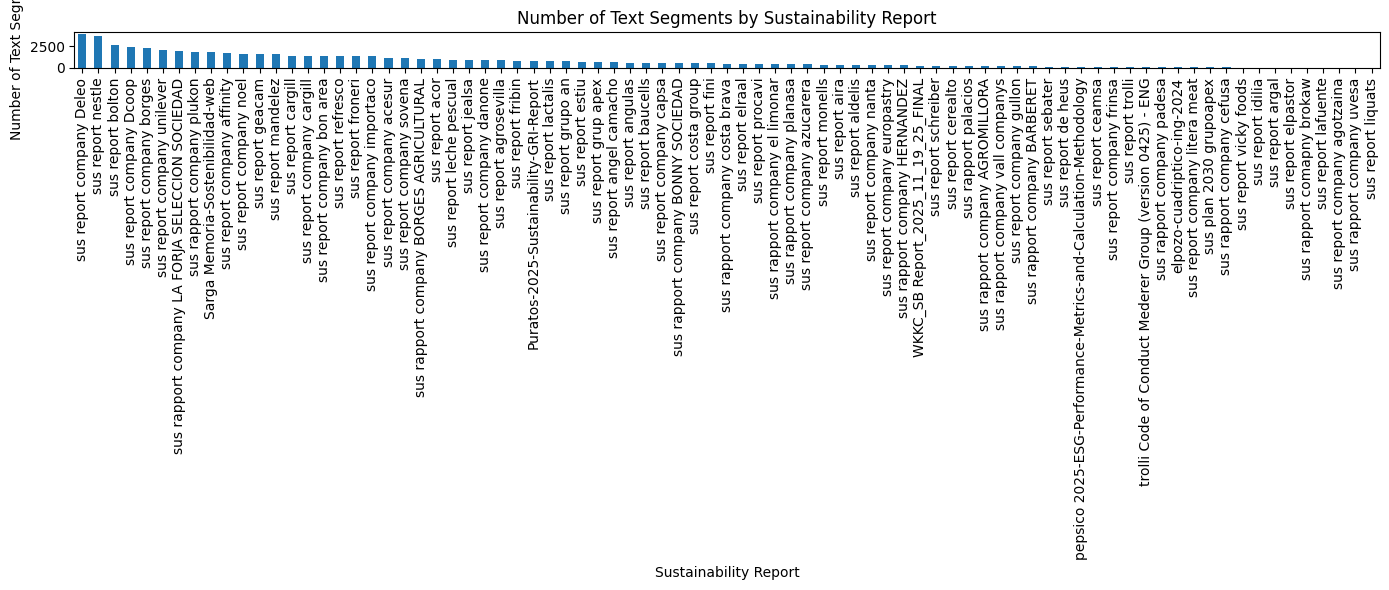

In [13]:
plt.figure(figsize=(14,6))

report_lengths.plot(kind="bar")

plt.title("Number of Text Segments by Sustainability Report")

plt.xlabel("Sustainability Report")

plt.ylabel("Number of Text Segments")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

# 9. ESG Report Characteristics

This section examines the textual characteristics of the sustainability reports included in the ESG corpus. Descriptive statistics such as report length and word distribution provide additional insight into the structure of the reports before applying Natural Language Processing techniques.

Understanding these characteristics helps contextualize the ESG corpus and supports the interpretation of subsequent analyses.

## 9.1 Distribution of Text Segment Lengths

The processed sustainability reports were divided into text segments to facilitate Natural Language Processing analyses. This subsection examines the distribution of segment lengths measured by the number of words.

The analysis helps evaluate the consistency of the preprocessing stage and provides an overview of the textual units that will be analyzed using FinBERT.

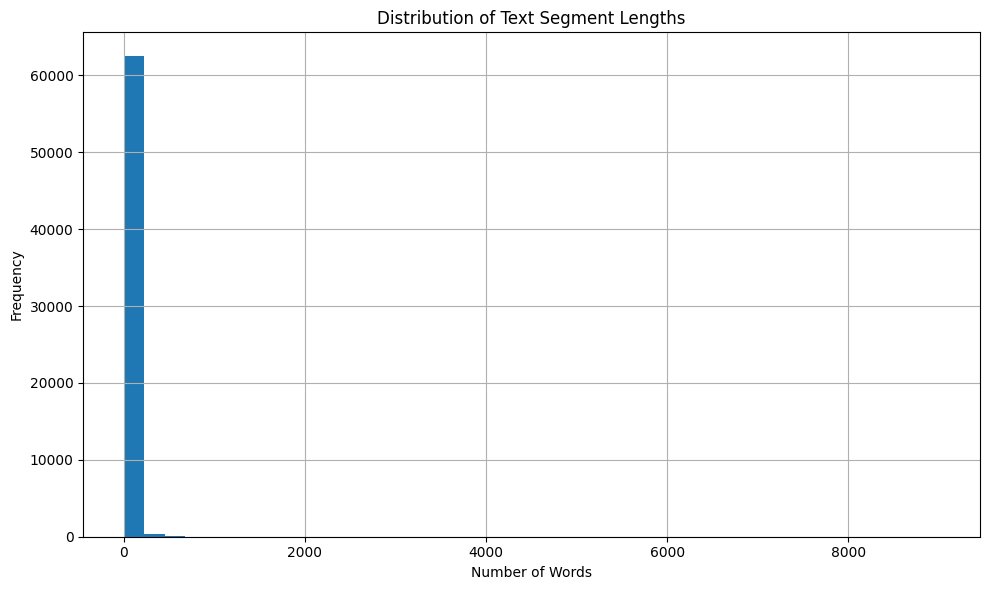

In [14]:
# ------------------------------------------------------------
# Distribution of text segment lengths
# ------------------------------------------------------------

plt.figure(figsize=(10,6))

documents_df["Word_Count"].hist(
    bins=40
)

plt.title("Distribution of Text Segment Lengths")

plt.xlabel("Number of Words")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

### Interpretation

The descriptive statistics provide an overview of the sustainability report corpus before ESG classification is performed. The distribution of text segment lengths indicates the variability in the amount of information contained within individual report segments and provides useful context for interpreting the subsequent ESG classification results.

In [19]:
!pip install transformers

from transformers import BertTokenizer, BertForSequenceClassification
import torch

# Load FinBERT ESG 9-category model
finbert = BertForSequenceClassification.from_pretrained(
    "yiyanghkust/finbert-esg-9-categories",
    num_labels=9
)

# Load tokenizer
tokenizer = BertTokenizer.from_pretrained(
    "yiyanghkust/finbert-esg-9-categories"
)

# GPU if available
if torch.cuda.is_available():
    device = torch.device("cuda")
    finbert.to(device)
    print("Using GPU:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    finbert.to(device)
    print("Using CPU")

config.json:   0%|          | 0.00/1.17k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  439MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  439MB            

model.safetensors: downloading bytes:           |  0.00B            

vocab.txt:   0%|          | 0.00/226k [00:00<?, ?B/s]

Using GPU: Tesla T4


# 10. Direct ESG Classification Using FinBERT-ESG

This section applies the pretrained FinBERT-ESG model directly to every English sentence extracted from the sustainability reports. Unlike the previous keyword-based approach, no predefined ESG vocabulary is used to identify Environmental, Social, or Governance content.

Instead, each sentence is passed directly to the FinBERT-ESG model, which assigns probabilities to the ESG categories based on its pretrained knowledge. The category with the highest probability is selected as the predicted ESG classification for that sentence.

This approach ensures that ESG classification is entirely data-driven and consistent with the methodology proposed by the FinBERT-ESG model.

In [16]:
print(df.columns)

Index(['Company', 'Sentence_ID', 'Original_Sentence', 'Cleaned_Sentence',
       'Word_Count'],
      dtype='object')


In [20]:
from scipy.special import softmax
import numpy as np

def classify_sentence(sentence):

    inputs = tokenizer(
        sentence,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=512
    ).to(device)

    with torch.no_grad():
        outputs = finbert(**inputs)[0]

    probs = softmax(
        outputs.cpu().numpy(),
        axis=1
    )

    pred = np.argmax(probs, axis=-1)

    label = finbert.config.id2label[pred[0]]

    score = np.max(probs, axis=-1)[0]

    return label, score, probs[0]

### FinBERT ESG Scores

In addition to the predicted ESG category, the probability assigned to each of the nine ESG categories is stored for every sentence. These probability scores provide a more detailed representation of the model's confidence and enable a comprehensive analysis of ESG-related disclosures across the sustainability reports.

In [35]:
from tqdm import tqdm
import pandas as pd

labels = [
    "Climate Change",
    "Natural Capital",
    "Pollution & Waste",
    "Human Capital",
    "Product Liability",
    "Community Relations",
    "Corporate Governance",
    "Business Ethics & Values",
    "Non-ESG"
]

results = []

for _, row in tqdm(documents_df.iterrows(), total=len(documents_df)):

    sentence = row["Original_Sentence"]

    # Skip missing values
    if pd.isna(sentence):
        continue

    # Convert to string
    sentence = str(sentence).strip()

    # Skip empty sentences
    if sentence == "":
        continue

    # Classify
    label, score, probs = classify_sentence(sentence)

    row_result = {
        "Report": row["Report"],
        "Sentence_ID": row["Sentence_ID"],
        "Original_Sentence": sentence,
        "Predicted_Label": label,
        "Confidence": score
    }

    # Save probabilities for all 9 ESG classes
    for i, category in enumerate(labels):
        row_result[category] = probs[i]

    results.append(row_result)

finbert_results = pd.DataFrame(results)

print("Done!")
print("Total classified sentences:", len(finbert_results))
print("Number of reports:", finbert_results["Report"].nunique())

finbert_results.head()

100%|██████████| 62895/62895 [10:24<00:00, 100.67it/s]


Done!
Total classified sentences: 62889
Number of reports: 81


,Report,Sentence_ID,Original_Sentence,Predicted_Label,Confidence,Climate Change,Natural Capital,Pollution & Waste,Human Capital,Product Liability,Community Relations,Corporate Governance,Business Ethics & Values,Non-ESG
0,Puratos-2025-Sustainability-GRI-Report,1,Better Life Planet Better Health Better 2025 S...,Community Relations,0.669794,0.008651,0.024660,0.003176,0.148677,0.116373,0.669794,0.003889,0.018458,0.006320
1,Puratos-2025-Sustainability-GRI-Report,2,"We serve artisans, retailers, industrial and f...",Community Relations,0.957433,0.002043,0.002630,0.001967,0.013891,0.008397,0.957433,0.000465,0.002806,0.010368
2,Puratos-2025-Sustainability-GRI-Report,3,"Our headquarters are located in Belgium, where...",Non-ESG,0.985053,0.000959,0.000719,0.001521,0.001271,0.002281,0.004321,0.002022,0.001852,0.985053
3,Puratos-2025-Sustainability-GRI-Report,4,"At Puratos, we believe that food has extraordi...",Natural Capital,0.338777,0.011894,0.338777,0.031826,0.005446,0.280969,0.295090,0.001927,0.029935,0.004137
4,Puratos-2025-Sustainability-GRI-Report,5,We do not take such a responsibility lightly.,Corporate Governance,0.647945,0.004224,0.001869,0.003052,0.130593,0.002249,0.003406,0.647945,0.200780,0.005882


In [37]:
print(documents_df.columns.tolist())

['Report', 'Sentence_ID', 'Original_Sentence', 'Cleaned_Sentence', 'Word_Count']


In [38]:
documents_df["Original_Sentence"].apply(type).value_counts()

,count
Original_Sentence,
<class 'str'>,62889
<class 'float'>,6


In [39]:
for idx, sentence in enumerate(documents_df["Original_Sentence"]):
    if pd.isna(sentence):
        continue

    if not isinstance(sentence, str):
        print(idx, type(sentence), sentence)
        break

### Interpretation

The FinBERT-ESG model assigns a probability score to each of the nine ESG categories for every sentence. The category with the highest probability is selected as the predicted ESG classification, while the complete set of probability scores provides additional information regarding the model's confidence across all ESG dimensions. Storing these scores enables a more detailed and transparent analysis of sustainability disclosures.

In [40]:
label_counts = (
    finbert_results["Predicted_Label"]
    .value_counts()
    .reset_index()
)

label_counts.columns = ["Category", "Count"]

label_counts

,Category,Count
0,Community Relations,16907
1,Non-ESG,12488
2,Natural Capital,6746
3,Human Capital,6726
4,Business Ethics & Values,6494
5,Climate Change,4823
6,Corporate Governance,3654
7,Product Liability,3025
8,Pollution & Waste,2026


### Interpretation

The FinBERT-ESG model successfully classified **62,889 English sentences extracted from 81 sustainability reports** into one of nine ESG-related categories. Unlike the previous keyword-based approach, the classification was performed directly by a pretrained transformer model, eliminating the need for manually defined ESG vocabularies. This methodology provides a more objective and context-aware classification of sustainability disclosures while preserving the probability scores for all nine ESG categories. These outputs form the basis for the subsequent quantitative analysis of ESG reporting patterns across the analyzed companies.

# 11. Distribution of FinBERT-ESG Categories

After classifying every sentence, the predicted ESG categories are aggregated to examine which sustainability themes are most frequently discussed across the sustainability reports.

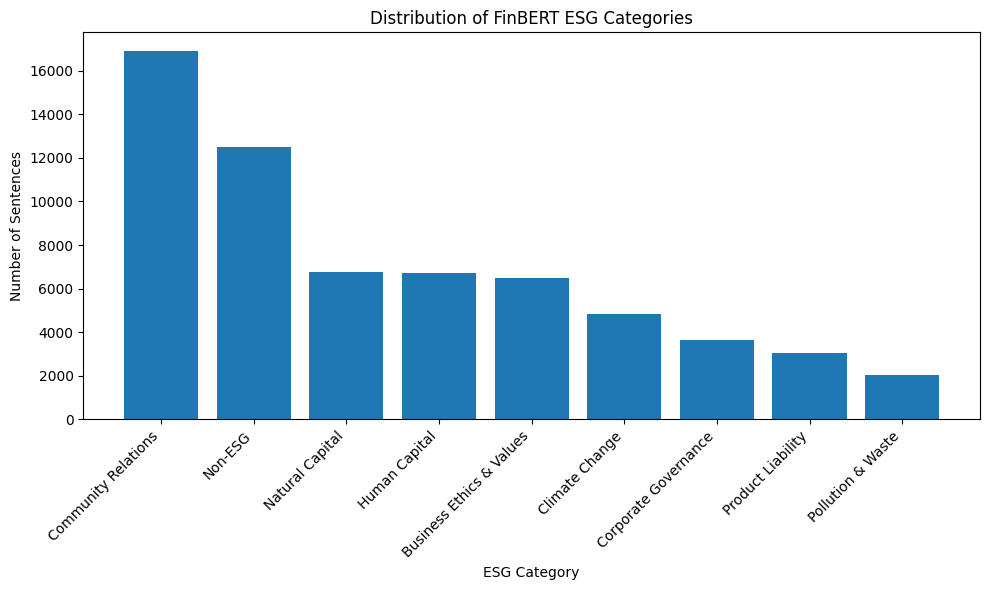

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(label_counts["Category"], label_counts["Count"])

plt.xticks(rotation=45, ha="right")

plt.ylabel("Number of Sentences")

plt.xlabel("ESG Category")

plt.title("Distribution of FinBERT ESG Categories")

plt.tight_layout()

plt.show()

### Interpretation

The bar chart summarizes the distribution of the ESG categories predicted by the FinBERT-ESG model across the **62,889 sentences extracted from 81 sustainability reports**. The frequencies indicate how often each ESG category appears in the analysed corpus, providing an overview of the sustainability topics most frequently discussed by the companies.

Differences in the category frequencies reflect the relative emphasis placed on various ESG dimensions within the reports. Categories with higher numbers of classified sentences correspond to themes that receive greater attention in corporate sustainability disclosures, whereas categories with lower frequencies represent topics that are discussed less extensively in the analysed dataset.

# 12. Distribution of FinBERT-ESG Categories

This section summarizes the ESG categories predicted by the pretrained FinBERT-ESG model for all extracted report sentences. Each sentence is assigned to one of the nine ESG categories according to the highest predicted probability.

The resulting distribution provides an overview of the sustainability topics most frequently discussed across the analyzed reports.

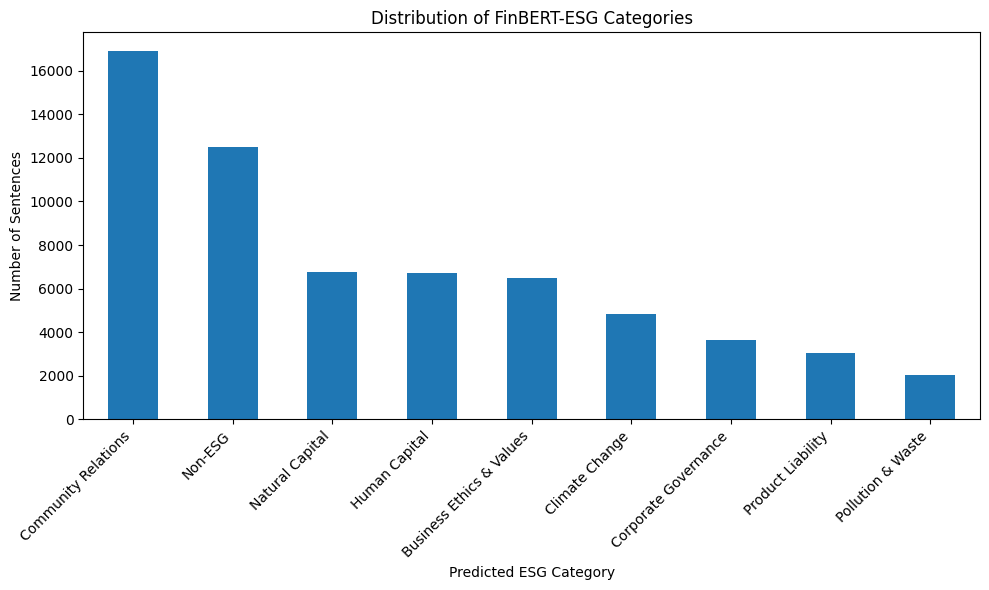

In [42]:
plt.figure(figsize=(10,6))

finbert_results["Predicted_Label"].value_counts().plot(
    kind="bar"
)

plt.title("Distribution of FinBERT-ESG Categories")

plt.xlabel("Predicted ESG Category")

plt.ylabel("Number of Sentences")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

### Interpretation

The bar chart presents the absolute number of sentences assigned to each ESG category by the FinBERT-ESG model across the **62,889 sentences extracted from 81 sustainability reports**. The results provide an overview of the sustainability topics most frequently discussed in the analysed reports. Categories with higher frequencies correspond to ESG themes that receive greater attention in corporate sustainability disclosures, whereas categories with fewer classified sentences indicate topics that are discussed less extensively.

### ESG Category Percentage Distribution

This section presents the percentage distribution of ESG categories predicted by the FinBERT-ESG model. The percentages indicate the proportion of report sentences assigned to each ESG category, providing a normalized view of the sustainability topics discussed across all analyzed reports.

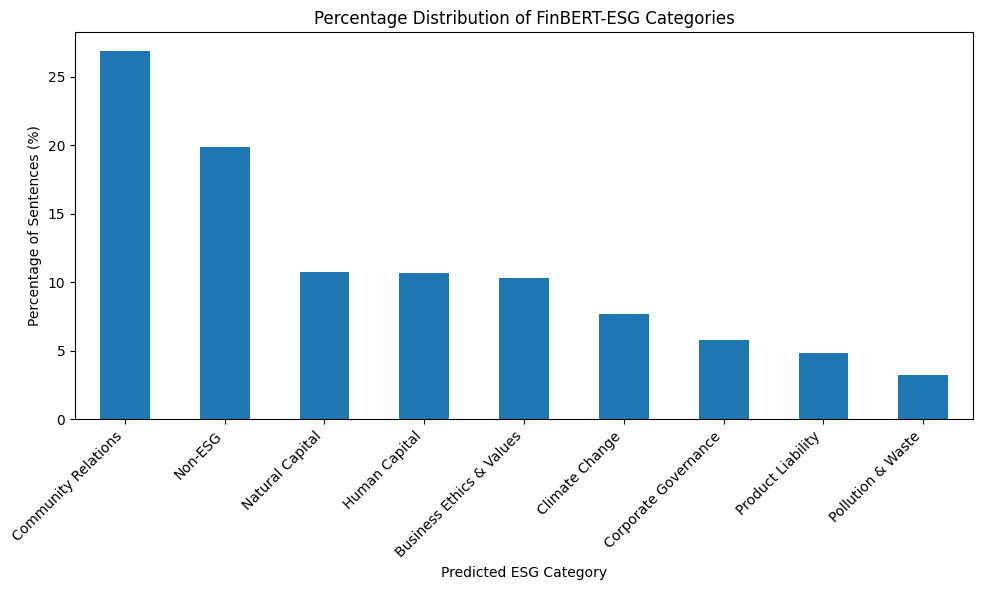

In [43]:
esg_percentage = (
    finbert_results["Predicted_Label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

plt.figure(figsize=(10,6))

esg_percentage.plot(kind="bar")

plt.title("Percentage Distribution of FinBERT-ESG Categories")

plt.xlabel("Predicted ESG Category")

plt.ylabel("Percentage of Sentences (%)")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

esg_percentage = (
    documents_df["ESG_Category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

esg_percentage.columns = [
    "ESG Category",
    "Percentage (%)"
]

display(esg_percentage)

### Interpretation

The percentage distribution provides a normalized representation of the ESG categories predicted by the FinBERT-ESG model across the complete dataset of **62,889 sentences from 81 sustainability reports**. Expressing the results as percentages facilitates comparisons between ESG categories by illustrating their relative contribution to the overall corpus, independent of the total number of classified sentences.

# 13. Export FinBERT-ESG Classification Results

The FinBERT-ESG classification results are exported to an Excel file for further analysis and documentation. The exported dataset contains the original report sentences together with their predicted ESG category, confidence score, and class probabilities generated by the FinBERT-ESG model.

This file provides a structured representation of the ESG classification results and can be used for subsequent quantitative analyses, visualization, or reporting activities.

In [44]:
# ------------------------------------------------------------
# Export FinBERT-ESG Classification Results
# ------------------------------------------------------------

output_file = "FinBERT_ESG_Classification.xlsx"

finbert_results.to_excel(
    output_file,
    index=False
)

print(f"Excel file created successfully: {output_file}")

Excel file created successfully: FinBERT_ESG_Classification.xlsx


In [45]:
import zipfile

zip_filename = "FinBERT_ESG_Classification.zip"

with zipfile.ZipFile(zip_filename, "w", zipfile.ZIP_DEFLATED) as zipf:
    zipf.write(output_file)

print(f"ZIP file created successfully: {zip_filename}")

ZIP file created successfully: FinBERT_ESG_Classification.zip


In [46]:
import os

print("Generated files:")

print(f"Excel: {os.path.abspath(output_file)}")

print(f"ZIP: {os.path.abspath(zip_filename)}")

Generated files:
Excel: /content/FinBERT_ESG_Classification.xlsx
ZIP: /content/FinBERT_ESG_Classification.zip


In [47]:
from google.colab import files

files.download(zip_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 14. Conclusions

This notebook applied a transformer-based Natural Language Processing (NLP) approach to analyse sustainability disclosures contained in corporate sustainability reports. A total of **62,889 English sentences extracted from 81 sustainability reports** were classified using the pretrained **FinBERT-ESG** model.

Unlike a rule-based keyword matching approach, FinBERT-ESG performs contextual classification by assigning each sentence to one of nine ESG-related categories while also providing probability scores for every category. This approach enables a more robust and context-aware identification of sustainability topics discussed within the reports.

The resulting ESG classifications provide a structured dataset that can be used for descriptive statistics, comparative analyses across companies, and downstream Natural Language Processing tasks. The classified dataset also serves as the input for the subsequent FinBERT sentiment analysis and BERTopic modelling presented in the following notebooks, enabling a comprehensive analysis of both the thematic content and sentiment expressed in corporate sustainability disclosures.